# Pump test analysis

Converted from `pump_test.py` into a Jupyter notebook.

Note: the original script saved the figure to a local Mac path. In this notebook, the plot is saved to a relative file `measured_vs_vendor_fit.png` instead.


Water measured — free fit (WLS via SciPy): Q = a f + b
  a = 0.101546 ± 0.007401
  b = 0.026550 ± 0.108412  (z = 0.24σ → YES)
  chi2/dof = 0.01/2

Water spec — free fit (WLS via SciPy): Q = a f + b
  a = 0.095353 ± 0.002298
  b = -0.015895 ± 0.044030  (z = -0.36σ → YES)
  chi2/dof = 4.18/8

HFE spec — free fit (WLS via SciPy): Q = a f + b
  a = 0.053846 ± 0.003172
  b = 0.141026 ± 0.058821  (z = 2.40σ → NO)
  chi2/dof = 0.00/0


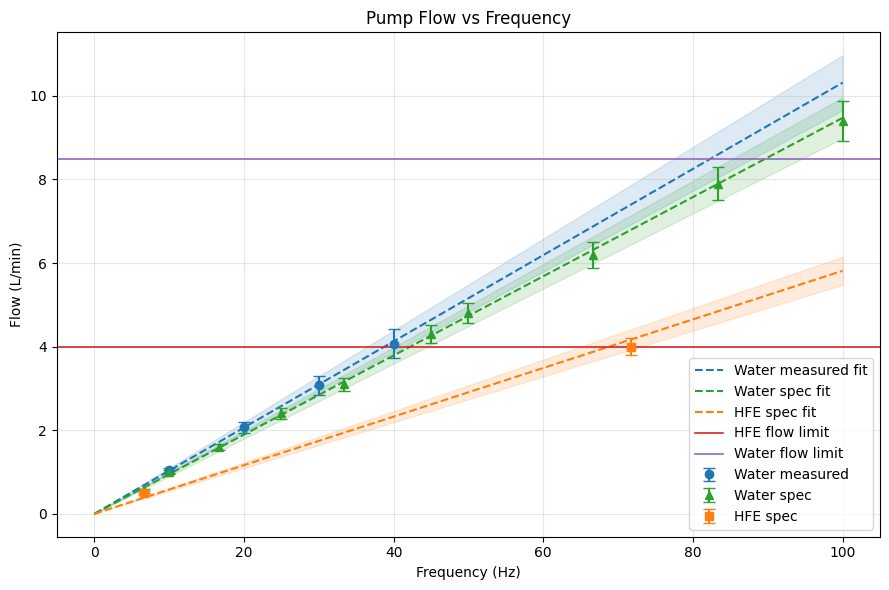


Fit equations (origin-constrained; envelope-based ± on slope m):
  Water measured: Q = (0.1032 ± 0.0066) f
  Water spec:     Q = (0.0947 ± 0.0049) f
  HFE spec:       Q = (0.0581  ± 0.0034) f


In [2]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===== Config you can tweak =====
frac_err_vendor = 0.05     # 1σ = 5% of Q for vendor water
frac_err_hfe    = 0.05     # 1σ = 5% of Q for HFE
min_abs_sigma   = 0.05     # L/min floor so weights never blow up

# ===== Data =====
# Measured (from 500 mL timing)
f_meas = np.array([10, 20, 30, 40], dtype=float)                 # Hz
t_meas = np.array([28.82, 14.52, 9.77, 7.37], dtype=float)       # s
V, sigma_V, sigma_t = 0.500, 0.05*0.500, 0.5
Q_meas = 60.0*V/t_meas
sigma_Q = np.sqrt((60.0/t_meas)**2 * sigma_V**2 + (60.0*V/t_meas**2)**2 * sigma_t**2)

# Vendor water points (digitized; no artificial (0,0) here)
vendor_rpm_Q = np.array([
    [200.0, 0.55],
    [300.0, 1.00],
    [500.0, 1.60],
    [750.0, 2.40],
    [1000.0, 3.10],
    [1350.0, 4.30],
    [1500.0, 4.80],
    [2000.0, 6.20],
    [2500.0, 7.90],
    [3000.0, 9.40],
], float)
f_vendor = vendor_rpm_Q[:,0]/30.0
Q_vendor = vendor_rpm_Q[:,1]
sigma_vendor = np.maximum(frac_err_vendor*Q_vendor, min_abs_sigma)

# HFE spec points (two points; no artificial (0,0))
f_hfe = np.array([200/30.0, 2150/30.0], float)
Q_hfe = np.array([0.5, 4.0], float)
sigma_hfe = np.maximum(frac_err_hfe*Q_hfe, min_abs_sigma)

# ===== WLS fits via SciPy =====
def fit_origin_with_band(f, Q, sig, f_grid):
    """
    Origin-constrained WLS using SciPy (absolute_sigma=True so sig are 1σ).
    Band: refit with (y+σ) and (y−σ) to form an envelope.
    """
    # central slope m
    m = curve_fit(lambda x, m: m*x, f, Q, sigma=sig, absolute_sigma=True)[0][0]
    # envelope from y±σ refits
    m_hi = curve_fit(lambda x, m: m*x, f, Q + sig, sigma=sig, absolute_sigma=True)[0][0]
    m_lo = curve_fit(lambda x, m: m*x, f, Q - sig, sigma=sig, absolute_sigma=True)[0][0]
    y_lo = np.minimum(m_lo * f_grid, m_hi * f_grid)
    y_hi = np.maximum(m_lo * f_grid, m_hi * f_grid)
    return m, m_lo, m_hi, y_lo, y_hi

def fit_axb_free(f, Q, sig):
    """Free two-parameter WLS using SciPy; returns params, errors, chi2/dof."""
    popt, pcov = curve_fit(lambda x, a, b: a*x + b, f, Q, sigma=sig, absolute_sigma=True)
    a, b = popt
    sa, sb = np.sqrt(np.diag(pcov))
    resid = Q - (a*f + b)
    chi2 = np.sum((resid / sig)**2)
    dof  = len(f) - 2
    return a, b, sa, sb, chi2, dof

# Grid
f_grid = np.linspace(0, 100, 600)

# Origin-constrained + envelopes
m_meas, m_meas_lo, m_meas_hi, Qm_lo, Qm_hi = fit_origin_with_band(f_meas, Q_meas, sigma_Q, f_grid)
m_vend, m_vend_lo, m_vend_hi, Qv_lo, Qv_hi = fit_origin_with_band(f_vendor, Q_vendor, sigma_vendor, f_grid)
m_hfe,  m_hfe_lo,  m_hfe_hi,  Qh_lo, Qh_hi = fit_origin_with_band(f_hfe,  Q_hfe,  sigma_hfe,  f_grid)

# Free (a,b) checks
def report_free(name, f, Q, sig):
    a, b, sa, sb, chi2, dof = fit_axb_free(f, Q, sig)
    z = b/sb if sb>0 else np.inf
    print(f"\n{name} — free fit (WLS via SciPy): Q = a f + b")
    print(f"  a = {a:.6f} ± {sa:.6f}")
    print(f"  b = {b:.6f} ± {sb:.6f}  (z = {z:.2f}σ → {'YES' if abs(z)<=2 else 'NO'})")
    print(f"  chi2/dof = {chi2:.2f}/{dof}")

report_free("Water measured", f_meas, Q_meas, sigma_Q)
report_free("Water spec",     f_vendor, Q_vendor, sigma_vendor)
report_free("HFE spec",       f_hfe,   Q_hfe,   sigma_hfe)

# ===== Plot (colors fixed: blue, green, orange) =====
plt.figure(figsize=(9, 6))

# Measured (blue)
plt.errorbar(f_meas, Q_meas, yerr=sigma_Q, fmt='o', capsize=4,
             color='tab:blue', ecolor='tab:blue', label='Water measured')
plt.plot(f_grid, m_meas*f_grid, '--', color='tab:blue', label='Water measured fit')
plt.fill_between(f_grid, Qm_lo, Qm_hi, color='tab:blue', alpha=0.15, label=None)

# Vendor water (green)
plt.errorbar(f_vendor, Q_vendor, yerr=sigma_vendor, fmt='^', capsize=4,
             color='tab:green', ecolor='tab:green', label='Water spec')
plt.plot(f_grid, m_vend*f_grid, '--', color='tab:green', label='Water spec fit')
plt.fill_between(f_grid, Qv_lo, Qv_hi, color='tab:green', alpha=0.15, label=None)

# HFE spec (orange)
plt.errorbar(f_hfe, Q_hfe, yerr=sigma_hfe, fmt='s', capsize=4,
             color='tab:orange', ecolor='tab:orange', label='HFE spec')
plt.plot(f_grid, m_hfe*f_grid, '--', color='tab:orange', label='HFE spec fit')
plt.fill_between(f_grid, Qh_lo, Qh_hi, color='tab:orange', alpha=0.15, label=None)

# Limits
plt.axhline(4.0, linewidth=1.2, color='tab:red',    label='HFE flow limit')
plt.axhline(8.5, linewidth=1.2, color='tab:purple', label='Water flow limit')

plt.xlabel('Frequency (Hz)'); plt.ylabel('Flow (L/min)')
plt.title('Pump Flow vs Frequency'); plt.grid(alpha=0.3)
plt.legend(loc='best'); plt.tight_layout()
output_plot = 'measured_vs_vendor_fit.png'
plt.show()

# ===== Console equations =====
print("\nFit equations (origin-constrained; envelope-based ± on slope m):")
print(f"  Water measured: Q = ({m_meas:.4f} ± {(m_meas_hi - m_meas_lo)/2:.4f}) f")
print(f"  Water spec:     Q = ({m_vend:.4f} ± {(m_vend_hi - m_vend_lo)/2:.4f}) f")
print(f"  HFE spec:       Q = ({m_hfe:.4f}  ± {(m_hfe_hi  - m_hfe_lo )/2:.4f}) f")